# Exploratory Data Analysis

## Objetivo

Evaluar la calidad, estructura y características de los cuatro datasets 
disponibles para determinar su viabilidad analítica y documentar las 
decisiones de limpieza que condicionarán los análisis posteriores.

## Datasets en scope

| # | Archivo | Uso previsto |
|---|---|---|
| 1 | eCommerce_Dataset.csv | Análisis de cohortes y ventas |
| 2 | events.csv | Análisis de funnel de comportamiento |
| 3 | Musical_instruments_reviews.csv | NLP y sentiment analysis |
| 4 | Instacart/*.csv | Modelo predictivo |

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
from utils import set_plot_style, ECOMMERCE_PATH, EVENTS_PATH, AMAZON_PATH, INSTACART_DIR

set_plot_style()

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

pandas  3.0.2
numpy   2.4.4


---
## 1. E-commerce Transactions (UK Retail 2010–2011)

Contiene transacciones de una tienda online de ropa entre 2010 y 2011. 
Fuente principal para el análisis de cohortes y ventas.

### Carga y vista general

In [2]:
df_ecom = pd.read_csv(ECOMMERCE_PATH, encoding='ISO-8859-1')

print(f"Shape: {df_ecom.shape}")
print(f"\nDtypes:\n{df_ecom.dtypes}")
df_ecom.head(10)

Shape: (541909, 8)

Dtypes:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


### Calidad de datos

In [3]:
nulls = df_ecom.isnull().sum()
null_pct = (nulls / len(df_ecom) * 100).round(2)

quality = pd.DataFrame({
    'null_count': nulls,
    'null_pct': null_pct,
    'dtype': df_ecom.dtypes,
    'unique_values': df_ecom.nunique()
})

print(quality)
print(f"\nDuplicados exactos: {df_ecom.duplicated().sum()}")
print(f"\nCancelaciones (InvoiceNo con 'C'): {df_ecom['InvoiceNo'].str.startswith('C').sum()}")
print(f"Quantity <= 0: {(df_ecom['Quantity'] <= 0).sum()}")
print(f"UnitPrice <= 0: {(df_ecom['UnitPrice'] <= 0).sum()}")

             null_count  null_pct    dtype  unique_values
InvoiceNo             0      0.00      str          25900
StockCode             0      0.00      str           4070
Description        1454      0.27      str           4223
Quantity              0      0.00    int64            722
InvoiceDate           0      0.00      str          23260
UnitPrice             0      0.00  float64           1630
CustomerID       135080     24.93  float64           4372
Country               0      0.00      str             38

Duplicados exactos: 5268

Cancelaciones (InvoiceNo con 'C'): 9288
Quantity <= 0: 10624
UnitPrice <= 0: 2517


### Análisis de registros problemáticos

Los conteos anteriores pueden solaparse entre sí. 
Antes de tomar decisiones de limpieza, es necesario entender 
cuántos registros únicos están afectados y si los problemas 
son independientes o se concentran en los mismos registros.

In [4]:
cancelled = df_ecom['InvoiceNo'].str.startswith('C')
qty_negative = df_ecom['Quantity'] <= 0
price_zero = df_ecom['UnitPrice'] <= 0
no_customer = df_ecom['CustomerID'].isnull()

print("Solapamiento entre registros problemáticos\n")
print(f"Cancelaciones Y Quantity <= 0: {(cancelled & qty_negative).sum()}")
print(f"Cancelaciones Y sin CustomerID: {(cancelled & no_customer).sum()}")
print(f"Quantity <= 0 Y sin CustomerID: {(qty_negative & no_customer).sum()}")
print(f"Price <= 0 Y sin CustomerID: {(price_zero & no_customer).sum()}")
print(f"\nRegistros con AL MENOS UN problema: {(cancelled | qty_negative | price_zero | no_customer).sum()}")
print(f"Registros limpios: {(~(cancelled | qty_negative | price_zero | no_customer)).sum()}")
print(f"\nDistribución de Quantity (percentiles):")
print(df_ecom['Quantity'].describe(percentiles=[.01, .25, .5, .75, .99]))
print(f"\nDistribución de UnitPrice (percentiles):")
print(df_ecom['UnitPrice'].describe(percentiles=[.01, .25, .5, .75, .99]))

Solapamiento entre registros problemáticos

Cancelaciones Y Quantity <= 0: 9288
Cancelaciones Y sin CustomerID: 383
Quantity <= 0 Y sin CustomerID: 1719
Price <= 0 Y sin CustomerID: 2477

Registros con AL MENOS UN problema: 144025
Registros limpios: 397884

Distribución de Quantity (percentiles):
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
1%           -2.000000
25%           1.000000
50%           3.000000
75%          10.000000
99%         100.000000
max       80995.000000
Name: Quantity, dtype: float64

Distribución de UnitPrice (percentiles):
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
1%            0.190000
25%           1.250000
50%           2.080000
75%           4.130000
99%          18.000000
max       38970.000000
Name: UnitPrice, dtype: float64


### Decisiones de limpieza

El análisis anterior revela que el dataset tiene dos capas de problemas 
con naturaleza distinta, que requieren tratamiento diferenciado.

**Registros a excluir en todos los análisis:**
- Cancelaciones (`InvoiceNo` con prefijo `C`): representan devoluciones, 
  no ventas. El solapamiento total con `Quantity <= 0` confirma que son 
  el mismo conjunto de registros.
- `Quantity <= 0` remanentes (1.336 registros no cancelaciones): 
  ajustes contables sin valor analítico.
- `UnitPrice <= 0`: el mínimo de -11.062 y los valores en cero indican 
  errores de carga o ítems internos, no transacciones reales.
- Duplicados exactos (5.268 registros).

**`CustomerID` nulo — tratamiento diferenciado:**
- El 24.93% de registros no tiene `CustomerID`. Excluirlos por completo 
  descartaría información válida de ventas y producto.
- Se generan dos versiones del dataset limpio:
  - `df_clean`: todas las transacciones válidas (sin restricción de cliente).
  - `df_customers`: subset de `df_clean` con `CustomerID` conocido. 
    Base exclusiva para cohortes y análisis de comportamiento por cliente.

In [5]:
df_clean = (
    df_ecom
    .drop_duplicates()
    .loc[~df_ecom['InvoiceNo'].str.startswith('C')]
    .loc[df_ecom['Quantity'] > 0]
    .loc[df_ecom['UnitPrice'] > 0]
    .copy()
)

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_customers = df_clean.dropna(subset=['CustomerID']).copy()
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)

print(f"df_ecom (original): {df_ecom.shape}")
print(f"df_clean (válidas): {df_clean.shape}")
print(f"df_customers (con ID): {df_customers.shape}")
print(f"\nRango de fechas: {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")
print(f"Países únicos: {df_clean['Country'].nunique()}")
print(f"Clientes únicos: {df_customers['CustomerID'].nunique()}")
print(f"\nNulos en df_clean:\n{df_clean.isnull().sum()}")

df_ecom (original): (541909, 8)
df_clean (válidas): (524878, 9)
df_customers (con ID): (392692, 9)

Rango de fechas: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Países únicos: 38
Clientes únicos: 4338

Nulos en df_clean:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
revenue             0
dtype: int64


### Distribución de revenue por país

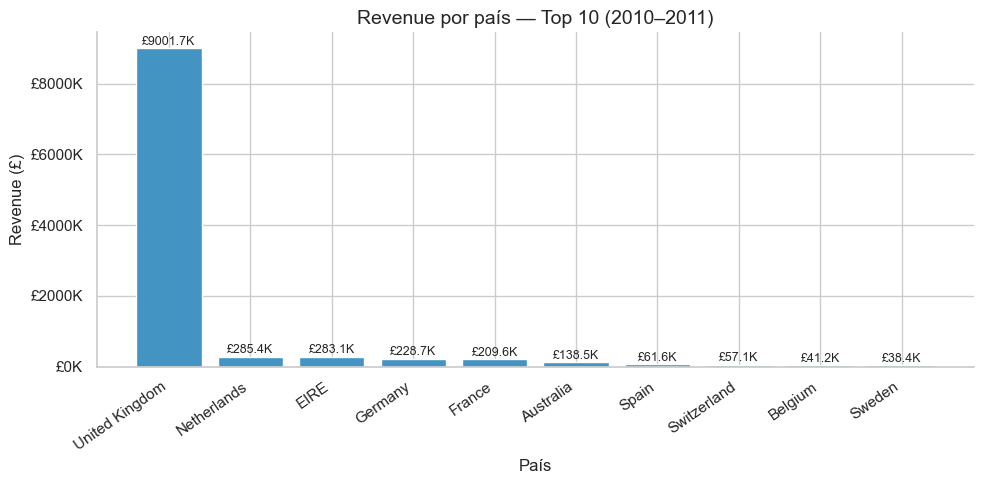

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

revenue_by_country = (
    df_clean
    .groupby('Country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

bars = ax.bar(revenue_by_country.index, revenue_by_country.values, color='#4393c3')

for bar, val in zip(bars, revenue_by_country.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'£{val/1e3:.1f}K',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('País')
ax.set_ylabel('Revenue (£)')
ax.set_title('Revenue por país — Top 10 (2010–2011)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
plt.xticks(rotation=35, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'ecommerce_revenue_by_country.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Retailrocket Events Dataset

Contiene eventos de comportamiento de usuarios en una plataforma de 
e-commerce: vistas de producto, agregados al carrito y transacciones. 
Fuente para el análisis de funnel de conversión.

### Carga y vista general

In [6]:
df_events = pd.read_csv(EVENTS_PATH)

print(f"Shape: {df_events.shape}")
print(f"\nDtypes:\n{df_events.dtypes}")
print(f"\nValores únicos por columna:")
print(df_events.nunique())
print(f"\nDistribución de eventos:")
print(df_events['event'].value_counts())
print(f"\nPrimeras filas:")
df_events.head(10)

Shape: (2756101, 5)

Dtypes:
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
dtype: object

Valores únicos por columna:
timestamp        2750455
visitorid        1407580
event                  3
itemid            235061
transactionid      17672
dtype: int64

Distribución de eventos:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Primeras filas:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


### Calidad de datos y parsing de timestamp

El campo `timestamp` está en Unix milliseconds. 
`transactionid` es `float64` porque solo está presente 
en eventos de tipo `transaction`, el resto son `NaN` por diseño.

In [7]:
print(f"Nulos por columna:")
print(df_events.isnull().sum())
print(f"\nDuplicados exactos: {df_events.duplicated().sum()}")

df_events['datetime'] = pd.to_datetime(df_events['timestamp'], unit='ms')

print(f"\nRango de fechas: {df_events['datetime'].min()} → {df_events['datetime'].max()}")
print(f"\nNulos en transactionid fuera de eventos transaction:")
non_tx = df_events[df_events['event'] != 'transaction']['transactionid'].isnull().sum()
tx_with_id = df_events[df_events['event'] == 'transaction']['transactionid'].notnull().sum()
print(f"  Eventos no-transaction con transactionid nulo: {non_tx} (esperado)")
print(f"  Eventos transaction con transactionid presente: {tx_with_id}")

Nulos por columna:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Duplicados exactos: 460

Rango de fechas: 2015-05-03 03:00:04.384000 → 2015-09-18 02:59:47.788000

Nulos en transactionid fuera de eventos transaction:
  Eventos no-transaction con transactionid nulo: 2733644 (esperado)
  Eventos transaction con transactionid presente: 22457


### Decisiones de limpieza

Los nulos en `transactionid` son estructurales, no errores: corresponden 
exactamente a los eventos `view` y `addtocart`, que no tienen transacción 
asociada por definición. No requieren tratamiento.

Se eliminan los 460 duplicados exactos. El dataset cubre 4,5 meses 
de actividad (mayo a septiembre 2015).

In [8]:
df_events_clean = df_events.drop_duplicates().copy()

print(f"Registros originales: {len(df_events):,}")
print(f"Registros limpios: {len(df_events_clean):,}")

total_visitors = df_events_clean['visitorid'].nunique()
visitors_view = df_events_clean[df_events_clean['event']=='view']['visitorid'].nunique()
visitors_cart = df_events_clean[df_events_clean['event']=='addtocart']['visitorid'].nunique()
visitors_tx   = df_events_clean[df_events_clean['event']=='transaction']['visitorid'].nunique()

print(f"\nFunnel de conversión (usuarios únicos)")
print(f"Visitantes totales: {total_visitors:,}")
print(f"Con al menos 1 view: {visitors_view:,}  ({visitors_view/total_visitors*100:.1f}%)")
print(f"Con al menos 1 addtocart: {visitors_cart:,}  ({visitors_cart/total_visitors*100:.1f}%)")
print(f"Con al menos 1 transaction: {visitors_tx:,}  ({visitors_tx/total_visitors*100:.1f}%)")
print(f"\nConversión view → addtocart: {visitors_cart/visitors_view*100:.2f}%")
print(f"Conversión addtocart → tx: {visitors_tx/visitors_cart*100:.2f}%")
print(f"Conversión end-to-end: {visitors_tx/visitors_view*100:.2f}%")

Registros originales: 2,756,101
Registros limpios: 2,755,641

Funnel de conversión (usuarios únicos)
Visitantes totales: 1,407,580
Con al menos 1 view: 1,404,179  (99.8%)
Con al menos 1 addtocart: 37,722  (2.7%)
Con al menos 1 transaction: 11,719  (0.8%)

Conversión view → addtocart: 2.69%
Conversión addtocart → tx: 31.07%
Conversión end-to-end: 0.83%


### Hallazgos del funnel

El drop más pronunciado ocurre en la etapa `view → addtocart` (2,69%), 
no en `addtocart → transaction` (31,07%). Esto indica que el problema 
de conversión está en el descubrimiento y consideración del producto, 
no en el proceso de compra en sí. Este dato alimentará directamente 
las oportunidades de negocio en el notebook 06.

### Visualización del funnel de conversión

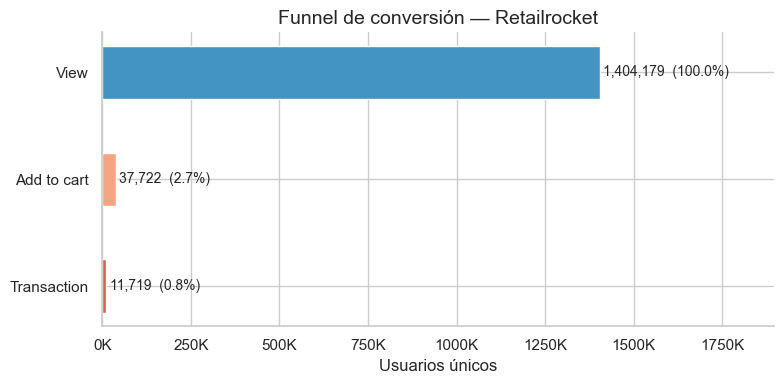

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

stages = ['View', 'Add to cart', 'Transaction']
values = [visitors_view, visitors_cart, visitors_tx]
colors = ['#4393c3', '#f4a582', '#d6604d']

bars = ax.barh(stages, values, color=colors, height=0.5)

for bar, val in zip(bars, values):
    pct = val / visitors_view * 100
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', fontsize=10)

ax.set_xlabel('Usuarios únicos')
ax.set_title('Funnel de conversión — Retailrocket')
ax.set_xlim(0, visitors_view * 1.35)
ax.invert_yaxis()
sns.despine()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'retailrocket_funnel.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Amazon Musical Instruments Reviews

Contiene reseñas de productos de instrumentos musicales en Amazon, 
con calificaciones numéricas y texto libre.
Fuente para el análisis de sentiment y NLP.

### Carga y vista general

In [9]:
df_amazon = pd.read_csv(AMAZON_PATH)

print(f"Shape: {df_amazon.shape}")
print(f"\nDtypes:\n{df_amazon.dtypes}")
print(f"\nNulos por columna:")
print(df_amazon.isnull().sum())
print(f"\nDistribución de ratings (overall):")
print(df_amazon['overall'].value_counts().sort_index())
df_amazon.head(5)

Shape: (10261, 9)

Dtypes:
reviewerID            str
asin                  str
reviewerName          str
helpful               str
reviewText            str
overall           float64
summary               str
unixReviewTime      int64
reviewTime            str
dtype: object

Nulos por columna:
reviewerID         0
asin               0
reviewerName      27
helpful            0
reviewText         7
overall            0
summary            0
unixReviewTime     0
reviewTime         0
dtype: int64

Distribución de ratings (overall):
overall
1.0     217
2.0     250
3.0     772
4.0    2084
5.0    6938
Name: count, dtype: int64


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


### Calidad de datos

In [10]:
import ast

print(f"Duplicados exactos: {df_amazon.duplicated().sum()}")
print(f"reviewText nulos: {df_amazon['reviewText'].isnull().sum()}")

df_amazon['helpful_votes'] = df_amazon['helpful'].apply(lambda x: ast.literal_eval(x)[0])
df_amazon['total_votes'] = df_amazon['helpful'].apply(lambda x: ast.literal_eval(x)[1])

print(f"\nDistribución de votos útiles:")
print(df_amazon['helpful_votes'].describe())

print(f"\nSesgo de ratings:")
rating_dist = df_amazon['overall'].value_counts(normalize=True).sort_index() * 100
for rating, pct in rating_dist.items():
    print(f"  {int(rating)} estrellas: {pct:.1f}%")

positivas = rating_dist[rating_dist.index >= 4].sum()
print(f"\n  Ratings >= 4 estrellas: {positivas:.1f}%")

Duplicados exactos: 0
reviewText nulos: 7

Distribución de votos útiles:
count    10261.00000
mean         1.57090
std          8.92045
min          0.00000
25%          0.00000
50%          0.00000
75%          1.00000
max        290.00000
Name: helpful_votes, dtype: float64

Sesgo de ratings:
  1 estrellas: 2.1%
  2 estrellas: 2.4%
  3 estrellas: 7.5%
  4 estrellas: 20.3%
  5 estrellas: 67.6%

  Ratings >= 4 estrellas: 87.9%


### Decisiones de limpieza

Se eliminan los 7 registros con `reviewText` nulo ya que el texto 
es el insumo principal del análisis de sentiment.

El dataset presenta un sesgo positivo marcado: el 87,9% de las reseñas 
tienen 4 o 5 estrellas. Esto es consistente con la distribución típica 
de Amazon y no constituye un error de datos. Sin embargo, condiciona 
el análisis posterior: la mayoría de los textos tendrán sentiment 
positivo, por lo que el valor analítico estará en las discrepancias, 
es decir, reseñas con rating alto pero sentiment negativo y viceversa.

In [11]:
df_amazon_clean = df_amazon.dropna(subset=['reviewText']).copy()
df_amazon_clean['overall'] = df_amazon_clean['overall'].astype(int)
df_amazon_clean['reviewTime'] = pd.to_datetime(df_amazon_clean['reviewTime'])

print(f"df_amazon original: {df_amazon.shape}")
print(f"df_amazon_clean: {df_amazon_clean.shape}")
print(f"\nRango temporal: {df_amazon_clean['reviewTime'].min()} → {df_amazon_clean['reviewTime'].max()}")
print(f"Productos únicos (asin): {df_amazon_clean['asin'].nunique()}")
print(f"Reviewers únicos: {df_amazon_clean['reviewerID'].nunique()}")

df_amazon original: (10261, 11)
df_amazon_clean: (10254, 11)

Rango temporal: 2004-09-18 00:00:00 → 2014-07-22 00:00:00
Productos únicos (asin): 900
Reviewers únicos: 1429


### Distribución de ratings

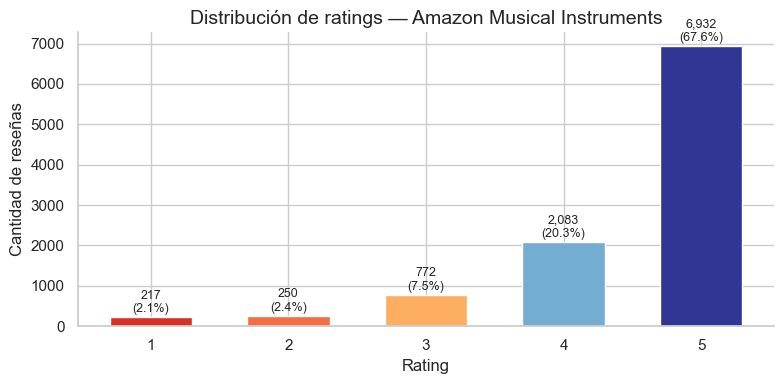

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

rating_counts = df_amazon_clean['overall'].value_counts().sort_index()
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#313695']

bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, width=0.6)

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df_amazon_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad de reseñas')
ax.set_title('Distribución de ratings — Amazon Musical Instruments')
ax.set_xticks([1, 2, 3, 4, 5])
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'amazon_rating_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### Hallazgos

10 años de reseñas (2004–2014), 900 productos y 1.429 reviewers únicos. 
El dataset es pequeño pero suficiente para NLP dado que cada registro 
contiene texto libre de longitud variable.

## 4. Instacart Market Basket Dataset

Seis archivos relacionales que representan el historial completo de pedidos de 
clientes en Instacart.

### Esquema relacional

`orders` → tabla central. Cada fila es un pedido de un usuario.  
`order_products__prior` → ítems de pedidos históricos (el grueso del historial).  
`order_products__train` → pedido más reciente de un subconjunto de usuarios (target del modelo).  
`products` → catálogo de productos.  
`aisles` y `departments` → jerarquía de categorías.

### Carga

In [12]:
instacart_path = os.path.join('..', 'data', 'Instacart')

orders = pd.read_csv(os.path.join(instacart_path, 'orders.csv'))
products = pd.read_csv(os.path.join(instacart_path, 'products.csv'))
aisles = pd.read_csv(os.path.join(instacart_path, 'aisles.csv'))
departments = pd.read_csv(os.path.join(instacart_path, 'departments.csv'))
prior = pd.read_csv(os.path.join(instacart_path, 'order_products__prior.csv'))
train = pd.read_csv(os.path.join(instacart_path, 'order_products__train.csv'))

datasets = {
    'orders': orders,
    'products': products,
    'aisles': aisles,
    'departments': departments,
    'order_products__prior': prior,
    'order_products__train': train
}

for name, df in datasets.items():
    print(f"{name:<25} shape: {str(df.shape):<15} nulls: {df.isnull().sum().sum()}")

orders                    shape: (3421083, 7)    nulls: 206209
products                  shape: (49688, 4)      nulls: 0
aisles                    shape: (134, 2)        nulls: 0
departments               shape: (21, 2)         nulls: 0
order_products__prior     shape: (32434489, 4)   nulls: 0
order_products__train     shape: (1384617, 4)    nulls: 0


### Análisis de la tabla `orders`

Los 206.209 nulos están concentrados en `orders`. 
Antes de asumir que son errores, es necesario identificar 
en qué columna están y si tienen una explicación estructural.

In [13]:
print("Nulos por columna en orders:")
print(orders.isnull().sum())

print(f"\nDistribución de eval_set:")
print(orders['eval_set'].value_counts())

print(f"\nUsuarios únicos por eval_set:")
print(orders.groupby('eval_set')['user_id'].nunique())

print(f"\nPrimeros pedidos por usuario (order_number == 1):")
first_orders = orders[orders['order_number'] == 1]
print(f"  Total: {len(first_orders):,}")
print(f"  Con days_since_prior_order nulo: {first_orders['days_since_prior_order'].isnull().sum():,}")

Nulos por columna en orders:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Distribución de eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Usuarios únicos por eval_set:
eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

Primeros pedidos por usuario (order_number == 1):
  Total: 206,209
  Con days_since_prior_order nulo: 206,209


### Estructura del dataset confirmada

Los 206.209 nulos en `days_since_prior_order` corresponden exactamente 
a los primeros pedidos de cada usuario (`order_number == 1`). 
Son nulos estructurales, no errores: un primer pedido no tiene 
pedido anterior por definición.

La distribución de `eval_set` define la arquitectura del dataset:
- `prior`: historial completo de pedidos. Base para feature engineering.
- `train`: pedido más reciente de 131.209 usuarios. Contiene el target (`reordered`).
- `test`: pedido más reciente de 75.000 usuarios sin target (era el set de competencia de Kaggle).

Para el modelo predictivo se usan `prior` para construir features 
y `train` como target. Los registros de `test` se excluyen 
porque no tienen ground truth disponible.

In [14]:
print("Columnas de order_products__prior:")
print(prior.head(3))

print(f"\nColumnas de order_products__train:")
print(train.head(3))

print(f"\nDistribución de reordered en train:")
print(train['reordered'].value_counts())
print(f"Tasa de reorden global: {train['reordered'].mean():.2%}")

print(f"\nPromedio de ítems por pedido (prior):")
print(prior.groupby('order_id')['product_id'].count().describe(
    percentiles=[.25, .5, .75, .99]
))

Columnas de order_products__prior:
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0

Columnas de order_products__train:
   order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0

Distribución de reordered en train:
reordered
1    828824
0    555793
Name: count, dtype: int64
Tasa de reorden global: 59.86%

Promedio de ítems por pedido (prior):
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
99%      3.500000e+01
max      1.450000e+02
Name: product_id, dtype: float64


### Decisiones para el modelo predictivo

La variable target se define a nivel ítem: `reordered = 1` si el 
producto fue comprado anteriormente por ese usuario. La tasa de reorden 
global es 59,86%, lo que indica un dataset moderadamente balanceado. 
No se requiere oversampling.

El set `test` queda excluido del modelado por ausencia de ground truth.

---
## Resumen ejecutivo del EDA

| Dataset | Registros limpios | Decisión clave |
|---|---|---|
| E-commerce | 392.692 (con CustomerID) | Separación df_clean / df_customers por nulos en CustomerID |
| Retailrocket | 2.755.641 | Nulos en transactionid son estructurales |
| Amazon Reviews | 10.254 | Dataset pequeño con sesgo positivo marcado (87,9% ≥ 4★) |
| Instacart orders | 3.421.083 | Nulos en days_since_prior_order son estructurales (primer pedido) |
| Instacart prior | 32.434.489 | Base para feature engineering |
| Instacart train | 1.384.617 | Target del modelo. Tasa de reorden: 59,86% |